<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/Park_math/%D0%B2%D1%8B%D1%87%D0%BC%D0%B5%D1%821_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Тема 1. Интерполирование функции с помощью
многочленов Лагранжа и многочленов Ньютона с разделенными разностями

Вариант 11

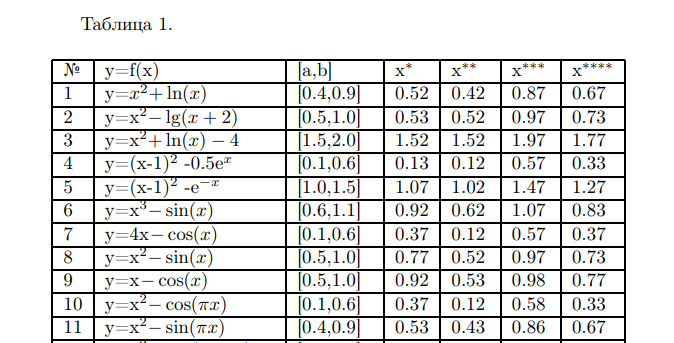

In [ ]:
import numpy as np
import math
from sympy import symbols, diff, lambdify

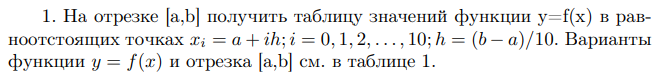

In [ ]:
f = lambda x: x**2 - np.sin(np.pi * x)  # y=f(x)
a, b = 0.4, 0.9                         # отрезок [a,b]
n_points = 10                           # количество интервалов -> 11 точек\узлов
x_star = 0.53                           # x* - точка интерполяции

# Шаг сетки
h = (b - a) / n_points
x_i = np.array([a + i * h for i in range(n_points + 1)])  # узлы интерполяции
y_i = f(x_i)  # значения функции в узлах

print(f"h = {h}")
print("=== Таблица значений функции ===")
print(f"{'i':>2} | {'x_i':>10} | {'f(x_i)':>10}")
print("-" * 50)
for i in range(len(x_i)):
    print(f"{i:>2} | {x_i[i]:>10.2f} | {y_i[i]:>10}")

h = 0.05
=== Таблица значений функции ===
 i |        x_i |     f(x_i)
--------------------------------------------------
 0 |       0.40 | -0.7910565162951535
 1 |       0.45 | -0.7851883405951378
 2 |       0.50 |      -0.75
 3 |       0.55 | -0.6851883405951376
 4 |       0.60 | -0.5910565162951534
 5 |       0.65 | -0.46850652418836786
 6 |       0.70 | -0.31901699437494735
 7 |       0.75 | -0.14460678118654757
 8 |       0.80 | 0.052214747707526876
 9 |       0.85 | 0.26850950026045367
10 |       0.90 | 0.5009830056250526


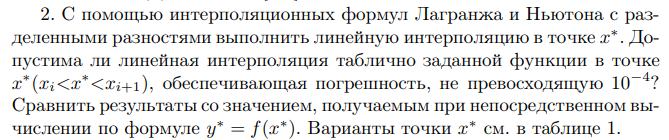


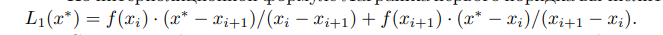

Так как х*=0,53 по таблице, то данная точка лежит между узлами x_2=0,5 и x_3=0,55
=>
x_2 < x* < x_3

In [ ]:
# линейная интерполяция (лагранж)
x_left = x_i[2]
x_right = x_i[3]
y_left = y_i[2]
y_right = y_i[3]

# формула лагранжа первого порядка
L1_lagrange = y_left * (x_star - x_right) / (x_left - x_right) + \
              y_right * (x_star - x_left) / (x_right - x_left)

print(f"=== линейная интерполяция (лагранж) ===")
print(f"узлы: x_2, x_3")
print(f"интерполяция в точке х*: L(0.53) = {L1_lagrange}")

# значение функции в x*
f_star = f(x_star)
print(f"точное значение функции в х*: f({x_star}) = {f_star}")

# погрешность
R1 = L1_lagrange - f_star
print(f"погрешность равна {R1} (|R1| = {abs(R1)})")

# проверка допустимости (≤ 1e-4)
if abs(R1) <= 1e-4:
    print("линейная интерполяция допустима (погрешность ≤ 1e-4)")
else:
    print("линейная интерполяция НЕ допустима (погрешность > 1e-4)")

=== линейная интерполяция (лагранж) ===
узлы: x_2, x_3
интерполяция в точке х*: L(0.53) = -0.7111130043570826
точное значение функции в х*: f(0.53) = -0.71466196460308
погрешность равна 0.003548960245997379 (|R1| = 0.003548960245997379)
линейная интерполяция НЕ допустима (погрешность > 1e-4)


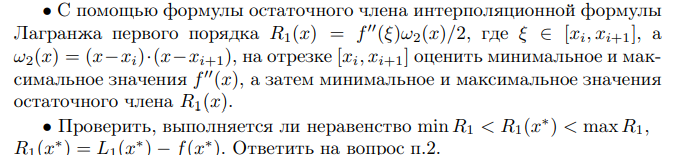

In [ ]:
# оценка остаточного члена для линейной интерполяции
# R1(x) = f''(ξ)/2 * (x - x_i)(x - x_{i+1})

def f_second_derivative(x):
    return 2 + (np.pi**2) * np.sin(np.pi * x)

# находим min и max f''(x) на [x_left, x_right]
x_vals_for_f2 = np.linspace(x_left, x_right, 1000)
f2_vals = f_second_derivative(x_vals_for_f2)
min_f2 = np.min(f2_vals)
max_f2 = np.max(f2_vals)

omega2 = (x_star - x_left) * (x_star - x_right)  # (x - x_i)(x - x_{i+1})

max_R1 = (min_f2 / 2) * omega2
min_R1 = (max_f2 / 2) * omega2

print(f"=== оценка остаточного члена R1 ===")
print(f"min f''(x) на [{x_left}, {x_right}] ≈ {min_f2:.4f}")
print(f"max f''(x) на [{x_left}, {x_right}] ≈ {max_f2:.4f}")
print(f"ω2(x*) = ({x_star}-{x_left}) * ({x_star}-{x_right}) = {omega2:.6f}")
print(f"min R1 = {min_R1:.6f}, (|min R1| = {abs(min_R1):.6f})")
print(f"max R1 = {max_R1:.6f}, (|max R1| = {abs(max_R1):.6f})")
print(f"R1 = {R1:.6f},      (|R1| = {abs(R1):.6f})")

print("\nфактическая погрешность попадает в теоретические границы")

=== оценка остаточного члена R1 ===
min f''(x) на [0.5, 0.55] ≈ 11.7481
max f''(x) на [0.5, 0.55] ≈ 11.8696
ω2(x*) = (0.53-0.5) * (0.53-0.55) = -0.000600
min R1 = -0.003561, (|min R1| = 0.003561)
max R1 = -0.003524, (|max R1| = 0.003524)
R1 = 0.003549,      (|R1| = 0.003549)

фактическая погрешность попадает в теоретические границы


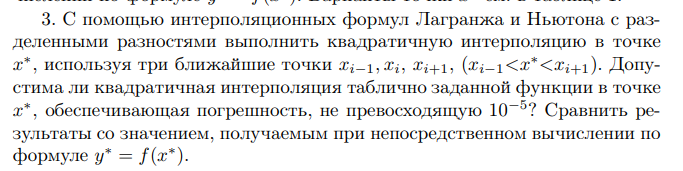

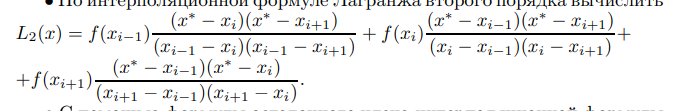

In [ ]:
# квадратичная интерполяция (лагранж)
# Три ближайшие точки: x_{i-1}, x_i, x_{i+1}

x_prev = x_i[1]
x_curr = x_i[2]
x_next = x_i[3]
y_prev = y_i[1]
y_curr = y_i[2]
y_next = y_i[3]

# формула лагранжа второго порядка
term1 = y_prev * (x_star - x_curr) * (x_star - x_next) / ((x_prev - x_curr) * (x_prev - x_next))
term2 = y_curr * (x_star - x_prev) * (x_star - x_next) / ((x_curr - x_prev) * (x_curr - x_next))
term3 = y_next * (x_star - x_prev) * (x_star - x_curr) / ((x_next - x_prev) * (x_next - x_curr))

L2_lagrange = term1 + term2 + term3

print(f"=== квадратичная интерполяция (лагранж) ===")
print(f"Узлы: x_1, x_2, x_3")
print(f"интерполяция в точке х*: L({x_star}) = {L2_lagrange}")
print(f"точное значение в х*: f({x_star}) = {f_star}")

# погрешность
R2 = L2_lagrange - f_star
print(f"погрешность R2 = {R2} (|R2| = {abs(R2)})")

# Проверка допустимости (≤ 1e-5)
if abs(R2) <= 1e-5:
    print("\nквадратичная интерполяция допустима (погрешность ≤ 1e-5)")
else:
    print("\nквадратичная интерполяция НЕ допустима (погрешность > 1e-5)")


=== квадратичная интерполяция (лагранж) ===
Узлы: x_1, x_2, x_3
интерполяция в точке х*: L(0.53) = -0.7146678026142494
точное значение в х*: f(0.53) = -0.71466196460308
погрешность R2 = -5.838011169490009e-06 (|R2| = 5.838011169490009e-06)

квадратичная интерполяция допустима (погрешность ≤ 1e-5)


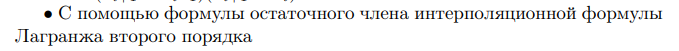
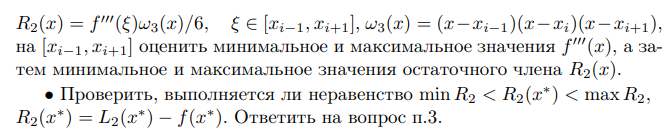

In [ ]:
# оценка остаточного члена для квадратичной интерполяции
# R2(x) = f'''(ξ)/6 * (x - x_{i-1})(x - x_i)(x - x_{i+1})

def f_third_derivative(x):
    return (np.pi**3) * np.cos(np.pi * x)

# min и max f'''(x) на [x_prev, x_next]
x_vals_for_f3 = np.linspace(x_prev, x_next, 1000)
f3_vals = f_third_derivative(x_vals_for_f3)
min_f3 = np.min(f3_vals)
max_f3 = np.max(f3_vals)

omega3 = (x_star - x_prev) * (x_star - x_curr) * (x_star - x_next)

min_R2 = (min_f3 / 6) * omega3
max_R2 = (max_f3 / 6) * omega3

print(f"=== оценка остаточного члена R2 ===")
print(f"min f'''(x) на [{x_prev}, {x_next:.2f}] ≈ {min_f3:.4f}")
print(f"max f'''(x) на [{x_prev}, {x_next:.2f}] ≈ {max_f3:.4f}")
print(f"ω3(x*) = ({x_star}-{x_prev}) * ({x_star}-{x_curr}) * ({x_star}-{x_next:.2f}) = {omega3:.6f}")
print(f"min R2 = {min_R2:.6f}, max R2 = {max_R2:.6f}")
print(f"фактическое R2 = {R2}")

print("\nфактическая погрешность попадает в границы теоретической погрешности")


=== оценка остаточного члена R2 ===
min f'''(x) на [0.45, 0.55] ≈ -4.8505
max f'''(x) на [0.45, 0.55] ≈ 4.8505
ω3(x*) = (0.53-0.45) * (0.53-0.5) * (0.53-0.55) = -0.000048
min R2 = 0.000039, max R2 = -0.000039
фактическое R2 = -5.838011169490009e-06

фактическая погрешность попадает в границы теоретической погрешности


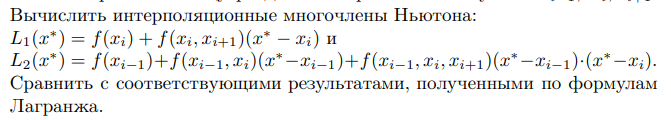

In [ ]:
# интерполяция по формуле ньютона
# линейная интерполяция ньютона (два узла: x_left, x_right)
f_x_left_x_right = (y_right - y_left) / (x_right - x_left)  # разделённая разность 1-го порядка

L1_newton = y_left + f_x_left_x_right * (x_star - x_left)

print(f"=== линейная интерполяция (ньютон) ===")
print(f"L1_newton({x_star}) = {L1_newton}")
print(f"L1_lagrange({x_star})={L1_lagrange}")
print(f"сравнение с лагранжем: {'совпадает' if abs(L1_newton - L1_lagrange) < 1e-16 else 'не совпадает'}")

# квадр интерполяция ньютона (три узла: x_prev, x_curr, x_next)
f_x_prev_x_curr = (y_curr - y_prev) / (x_curr - x_prev)
f_x_curr_x_next = (y_next - y_curr) / (x_next - x_curr)
f_x_prev_x_curr_x_next = (f_x_curr_x_next - f_x_prev_x_curr) / (x_next - x_prev)

L2_newton = (y_prev + f_x_prev_x_curr * (x_star - x_prev) +
            f_x_prev_x_curr_x_next * (x_star - x_prev) * (x_star - x_curr))

print(f"=== квадратичная интерполяция (ньютон) ===")
print(f"L2_newton({x_star}) = {L2_newton}")
print(f"L2_lagrange({x_star})={L2_lagrange}")
print(f"сравнение с лагранжем: {'совпадает' if abs(L2_newton - L2_lagrange) < 1e-16 else 'не совпадает'}")


=== линейная интерполяция (ньютон) ===
L1_newton(0.53) = -0.7111130043570826
L1_lagrange(0.53)=-0.7111130043570826
сравнение с лагранжем: совпадает
=== квадратичная интерполяция (ньютон) ===
L2_newton(0.53) = -0.7146678026142496
L2_lagrange(0.53)=-0.7146678026142494
сравнение с лагранжем: не совпадает


In [ ]:
print("=== таблица разделённых разностей ===")
print(f"{'x':<8} {'f[x]':<30} {'f[x,x]':<30} {'f[x,x,x]':<30}")
print("-"*40)
print(f"{x_prev:<8.2f} {y_prev:<30} {'':<30} {'':<30}")
print(f"{x_curr:<8.2f} {y_curr:<30} {f_x_prev_x_curr:<30} {'':<30}")
print(f"{x_next:<8.2f} {y_next:<30} {f_x_curr_x_next:<30} {f_x_prev_x_curr_x_next:<30}")

=== таблица разделённых разностей ===
x        f[x]                           f[x,x]                         f[x,x,x]                      
----------------------------------------
0.45     -0.7851883405951378                                                                         
0.50     -0.75                          0.7037668119027553                                           
0.55     -0.6851883405951376            1.2962331880972477             5.924663761944923             


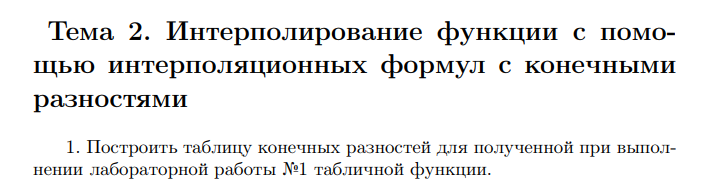

In [ ]:
def divided_differences(x, y):
    n = len(y)
    # Создаем таблицу разделённых разностей
    F = np.zeros((n, n))
    F[:, 0] = y  # первая колонка — значения функции

    for j in range(1, n):
        for i in range(n - j):
            F[i, j] = (F[i+1, j-1] - F[i, j-1]) / (x[i+j] - x[i])

    return F

In [ ]:
def build_finite_diff_table(y):
    n = len(y)
    diff_table = np.zeros((n, n))
    diff_table[:, 0] = y  # нулевой столбец — значения функции

    # заполняем таблицу разностями
    for j in range(1, n):          # j — порядок разности
        for i in range(n - j):     # i — индекс строки
            diff_table[i, j] = diff_table[i+1, j-1] - diff_table[i, j-1]

    return diff_table

diff_table = build_finite_diff_table(y_i)

# формируем заголовки и строки для вывода
headers = ["i", "xᵢ"] + [f"Δ^{k}yᵢ" for k in range(len(y_i))]

rows = []
for i in range(len(x_i)):
    row = [i, f"{x_i[i]:.2f}"]
    for j in range(len(y_i) - i):
        val = diff_table[i, j]
        row.append(f"{val:.6f}" if abs(val) > 1e-8 else "0.000000")
    rows.append(row)

print("таблица конечных разностей")
print("="*60)
print(f"{'i':>2} {'xᵢ':>6} {'yᵢ':>30} {'Δ¹yᵢ':>30} {'Δ²yᵢ':>30} {'Δ³yᵢ':>30} {'Δ⁴yᵢ':>30} {'Δ⁵yᵢ':>30} {'Δ⁶yᵢ':>30} {'Δ⁷yᵢ':>30} {'Δ⁸yᵢ':>30} {'Δ⁹yᵢ':>30} {'Δ¹⁰yᵢ':>30}")

for i in range(len(x_i)):
    row = [f"{i:>2}", f"{x_i[i]:>6.2f}"]
    for j in range(len(y_i) - i):
        val = diff_table[i, j]
        row.append(f"{val:>30}" if abs(val) > 1e-8 else "  0.000000")
    print(" ".join(row))

таблица конечных разностей
 i     xᵢ                             yᵢ                           Δ¹yᵢ                           Δ²yᵢ                           Δ³yᵢ                           Δ⁴yᵢ                           Δ⁵yᵢ                           Δ⁶yᵢ                           Δ⁷yᵢ                           Δ⁸yᵢ                           Δ⁹yᵢ                          Δ¹⁰yᵢ
 0   0.40            -0.7910565162951535           0.005868175700015743           0.029320164895122014          0.0003031539146026718         -0.0006063078292056767          7.464655488453875e-06         1.4745506382474183e-05         -5.468878962466839e-07           -3.4961710693171e-07         2.2074918060166482e-08   0.000000
 1   0.45            -0.7851883405951378            0.03518834059513776           0.029623318809724686         -0.0003031539146030049         -0.0005988431737172228         2.2210161870928058e-05         1.4198618486227499e-05         -8.965050031783939e-07         -3.275421888715435e-07   

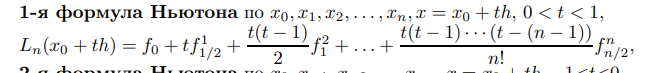

Условия 0<t<1 выполняются

---

t = 0,6

In [ ]:
import numpy as np

# Определение функции
f = lambda x: x**2 - np.sin(np.pi * x)
a, b = 0.4, 0.9
n_points = 10  # количество интервалов -> 11 точек
x_double_star = 0.43  # точка интерполяции x**

# Шаг сетки
h = (b - a) / n_points
x_i = np.array([a + i * h for i in range(n_points + 1)])  # узлы
y_i = f(x_i)  # значения функции

F = divided_differences(x_i, y_i)

def newton_interpolation(x, x_nodes, F):
    n = len(x_nodes)
    result = F[0, 0]
    term = 1.0

    for j in range(1, n):
        term *= (x - x_nodes[j-1])
        result += F[0, j] * term

    return result

# Вычисляем P_10(x**)
P_10_xstar = newton_interpolation(x_double_star, x_i, F)

# Точное значение
f_xstar = f(x_double_star)

# Погрешность
R_newton = abs(P_10_xstar - f_xstar)

print(f"=== Интерполяция по Ньютону (все 11 узлов) для x** = {x_double_star} ===")
print(f"Значение по Ньютону:     {P_10_xstar}")
print(f"Точное значение:         {f_xstar}")
print(f"Абсолютная погрешность:  {R_newton}")

if R_newton < 1e-16:
    print("Погрешность меньше 1e-16")
else:
    print("Погрешность больше 1e-16")

=== Интерполяция по Ньютону (все 11 узлов) для x** = 0.43 ===
Значение по Ньютону:     -0.7910167619352586
Точное значение:         -0.7910167619387474
Абсолютная погрешность:  3.488764832582092e-12
Погрешность больше 1e-16


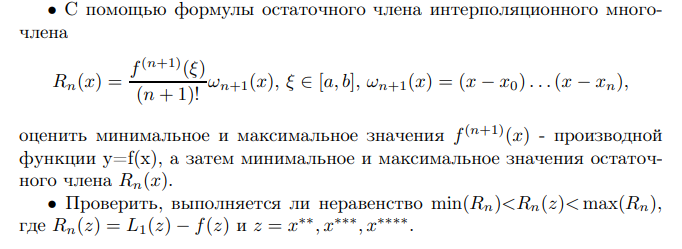

In [ ]:
# оценка остаточного члена (теоретическая)
import math

def f_11th_derivative(x): # f^(11)(x) = π^11 * cos(πx)
    return (np.pi**11) * np.cos(np.pi * x)

max_f_11th = np.pi**11

omega_11 = 1.0
for x_node in x_i:
    omega_11 *= (x_double_star - x_node)

factorial_11 = math.factorial(11)
pi_11 = math.pi ** 11

print(f"Максимальное |f^(11)(x)| на [0.4, 0.9]: π¹¹ ≈ {pi_11:.2f}")

factorial_11 = math.factorial(11)

max_R_10 = (pi_11 / factorial_11) * abs(omega_11)

print(f"Теоретическая оценка |R_10(x**)| <= {max_R_10}")

print(f"Фактическая погрешность |R| = {abs(R_newton)}")

if abs(R_newton) <= max_R_10:
    print("Фактическая погрешность <= теоретической оценки")
else:
    print("Фактическая погрешность > теоретической оценки")


Максимальное |f^(11)(x)| на [0.4, 0.9]: π¹¹ ≈ 294204.02
Теоретическая оценка |R_10(x**)| <= 8.767133810429034e-12
Фактическая погрешность |R| = 3.488764832582092e-12
Фактическая погрешность <= теоретической оценки


# интерполяция точки х**** по формуле гауса

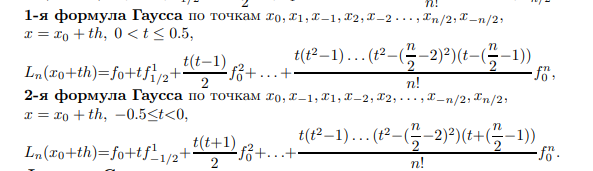

точка х****=0,67

ближайшая точка х_5=0,65

t = (x****-x_5)/h = (0,67-0,65)/0,05 = 0,4

t>0 => используем первую формулу гауса

L_n(x_0+th) = L_n(x****)

x_0 + th = x**** => 0,65 + 0,4 * 0,05

=>

x_0 = x_5 в формуле гауса

In [ ]:
# переставим узлы в порядке, симметричном относительно x****=0.67
sorted_indices = np.argsort(np.abs(x_i - x_star))
x_sorted = x_i[sorted_indices]
y_sorted = y_i[sorted_indices]

F_gauss = np.zeros((len(y_sorted), len(y_sorted)))
F_gauss[:, 0] = y_sorted

# построим таблицу разделённых разностей для пересортированных узлов
for j in range(1, len(y_sorted)):
    for i in range(len(y_sorted) - j):
        F_gauss[i, j] = (F_gauss[i+1, j-1] - F_gauss[i, j-1]) / (x_sorted[i+j] - x_sorted[i])

# вычисляем значение в x****
def interpolation(x, x_nodes, F):
    n = len(x_nodes)
    result = F[0, 0]
    term = 1.0
    for j in range(1, n):
        term *= (x - x_nodes[j-1]) # (x - x0)(x - x1)...(x - x_{j-1})
        result += F[0, j] * term   # + f[x0,x1,...,xj] * term
    return result

P_gauss = interpolation(x_star, x_sorted, F_gauss)
f_exact = f(x_star)
error = abs(P_gauss - f_exact)

print(f"\n=== Интерполяция по Гауссу (симметричные узлы) для x**** = {x_star} ===")
print(f"Значение по Гауссу:     {P_gauss:.18f}")
print(f"Точное значение:         {f_exact:.18f}")
print(f"Абсолютная погрешность:  {error:.2e}")

if error < 1e-16:
    print("Погрешность меньше 1e-16")
else:
    print("Погрешность больше 1e-16")


=== Интерполяция по Гауссу (симметричные узлы) для x**** = 0.53 ===
Значение по Гауссу:     -0.714661964602885003
Точное значение:         -0.714661964603079958
Абсолютная погрешность:  1.95e-13
Погрешность больше 1e-16


In [ ]:
# оценка остаточного члена (теоретическая)

max_R_theory = max_f_11th / factorial_11 * abs(omega_11)

print(f"Теоретическая оценка погрешности <= {max_R_theory:.2e}")

print(f"фактическая погрешность R = {error}")

if error <= max_R_theory:
    print("Фактическая погрешность <= теоретической оценки")
else:
    print("Фактическая погрешность > теоретической оценки")

Теоретическая оценка погрешности <= 8.77e-12
фактическая погрешность R = 1.949551631241775e-13
Фактическая погрешность <= теоретической оценки


# Тема 3

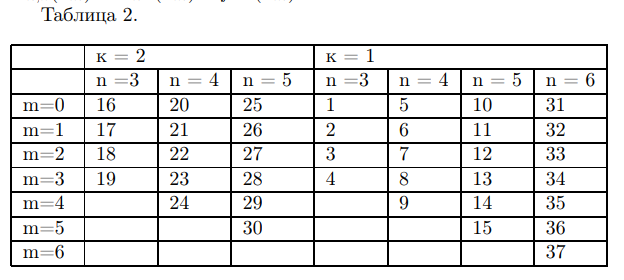

Вариант 26

m=1 — номер точки

n=5 — используем 6 узлов (от x0 до x5)

k=2 — порядок производной

y=x^2−sin(πx)

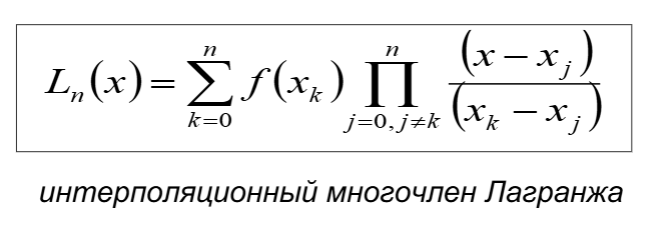

Построить интерполяционный многочлен Лагранжа по 6 точкам, продифференцировать его два раза и вычислить приближённое значение второй производной в точке x_1=0.45 . Сравнить с точным значением f ′′ (0.45).

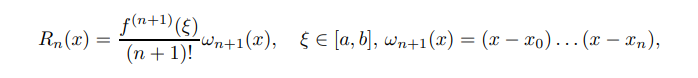

In [ ]:
# f^(6)(x) = π^6 * sin(πx)

omega_6_sym = 1

for xi in x_i[:6]:
    omega_6_sym *= (x_sym - xi)

omega_6_double_diff = diff(omega_6_sym, x_sym, 2)

omega_6_at_x1 = float(omega_6_double_diff.subs(x_sym, x_i[1]))

# Максимальное значение: |f^(6)(x)| <= π^6
f_6_max = np.pi**6

# R_5''(x_m) = [f^(6)(ξ) / 6!] * ω_6''(x_m)
factorial_6 = 720
theoretical_error_bound = (f_6_max / factorial_6) * abs(omega_6_at_x1)

print(f"Теоретическая оценка погрешности: {theoretical_error_bound}")

print(f"Фактическая погрешность: {error}")

if error < theoretical_error_bound:
    print("Фактическая погрешность < теоретической оценки")
else:
    print("Фактическая погрешность > теоретической оценки")

print(abs(L_double_diff_at_x1-L_double_prime_x1))

Теоретическая оценка погрешности: 0.00043396039987774154
Фактическая погрешность: 1.949551631241775e-13
Фактическая погрешность < теоретической оценки
1.999724474899267e-08


In [ ]:
f = lambda x: x**2 - np.sin(np.pi * x)  # y=f(x)
a, b = 0.4, 0.9                         # отрезок [a,b]
n_points = 100                           # количество интервалов -> 11 точек\узлов


# Шаг сетки
h = (b - a) / n_points
x_i = np.array([a + i * h for i in range(n_points + 1)])  # узлы интерполяции
y_i = f(x_i)  #

In [ ]:
# Символьные вычисления с помощью SymPy
x_sym = symbols('x')
L = 0

# Строим многочлен Лагранжа
for j in range(6):
    lj = 1
    for i in range(6):
        if i != j:
            lj *= (x_sym - x_i[i]) / (x_i[j] - x_i[i])
    L += y_i[j] * lj

# Дважды дифференцируем
#L_prime2 = diff(L, x_sym, 2)
#L_prime2_func = lambdify(x_sym, L_prime2, 'numpy')
#L_double_diff_at_x1 = L_prime2_func(x_i[1])

# Вычисляем в точке x_m (x1 = 0.45)
L_double_diff_at_x1 = lambdify(x_sym, diff(L, x_sym, 2), 'numpy')(x_i[1])

# Точное значение второй производной
f_double_diff_exact = 2 + np.pi**2 * np.sin(np.pi * x_i[1])

# Погрешность
error = abs(L_double_diff_at_x1 - f_double_diff_exact)

print(f"=== Результат дифференцирования ===")
print(f"Значение по Лагранжу (вторая производная в x1=0.45): {L_double_diff_at_x1}")
print(f"Точное значение: {f_double_diff_exact}")
print(f"Погрешность: {error}")

=== Результат дифференцирования ===
Значение по Лагранжу (вторая производная в x1=0.45): 11.433298967086317
Точное значение: 11.433298945384065
Погрешность: 2.170225243958157e-08


In [ ]:
# Коэффициенты из формулы
L_double_prime_x1 = (
    (5/6) * y_i[0]
    - (5/4) * y_i[1]
    - (1/3) * y_i[2]
    + (7/6) * y_i[3]
    - (1/2) * y_i[4]
    + (1/12) * y_i[5]
) / (h**2)

print(f"L''(x1):        {L_double_prime_x1}")
print(f"точное f''(x1): {f_double_diff_exact}")
print(f"погрешность:    {abs(L_double_prime_x1 - f_double_diff_exact)}")

L''(x1):        11.433298987083562
точное f''(x1): 11.433298945384065
погрешность:    4.169949718857424e-08


In [ ]:
# f^(6)(x) = π^6 * sin(πx)

omega_6_sym = 1

for xi in x_i[:6]:
    omega_6_sym *= (x_sym - xi)

omega_6_double_diff = diff(omega_6_sym, x_sym, 2)

omega_6_at_x1 = float(omega_6_double_diff.subs(x_sym, x_i[1]))

# Максимальное значение: |f^(6)(x)| <= π^6
f_6_max = np.pi**6

# R_5''(x_m) = [f^(6)(ξ) / 6!] * ω_6''(x_m)
factorial_6 = 720
theoretical_error_bound = (f_6_max / factorial_6) * abs(omega_6_at_x1)

print(f"Теоретическая оценка погрешности: {theoretical_error_bound}")

print(f"Фактическая погрешность: {error}")

if abs(L_double_prime_x1 - f_double_diff_exact) < theoretical_error_bound:
    print("Фактическая погрешность < теоретической оценки")
else:
    print("Фактическая погрешность > теоретической оценки")

Теоретическая оценка погрешности: 4.339603998777431e-08
Фактическая погрешность: 2.170225243958157e-08
Фактическая погрешность < теоретической оценки
